1. Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


2. Load dataset

In [3]:
df = pd.read_csv("../Data/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


3. EDA 

In [4]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [5]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

4. Preprocessing

<Axes: >

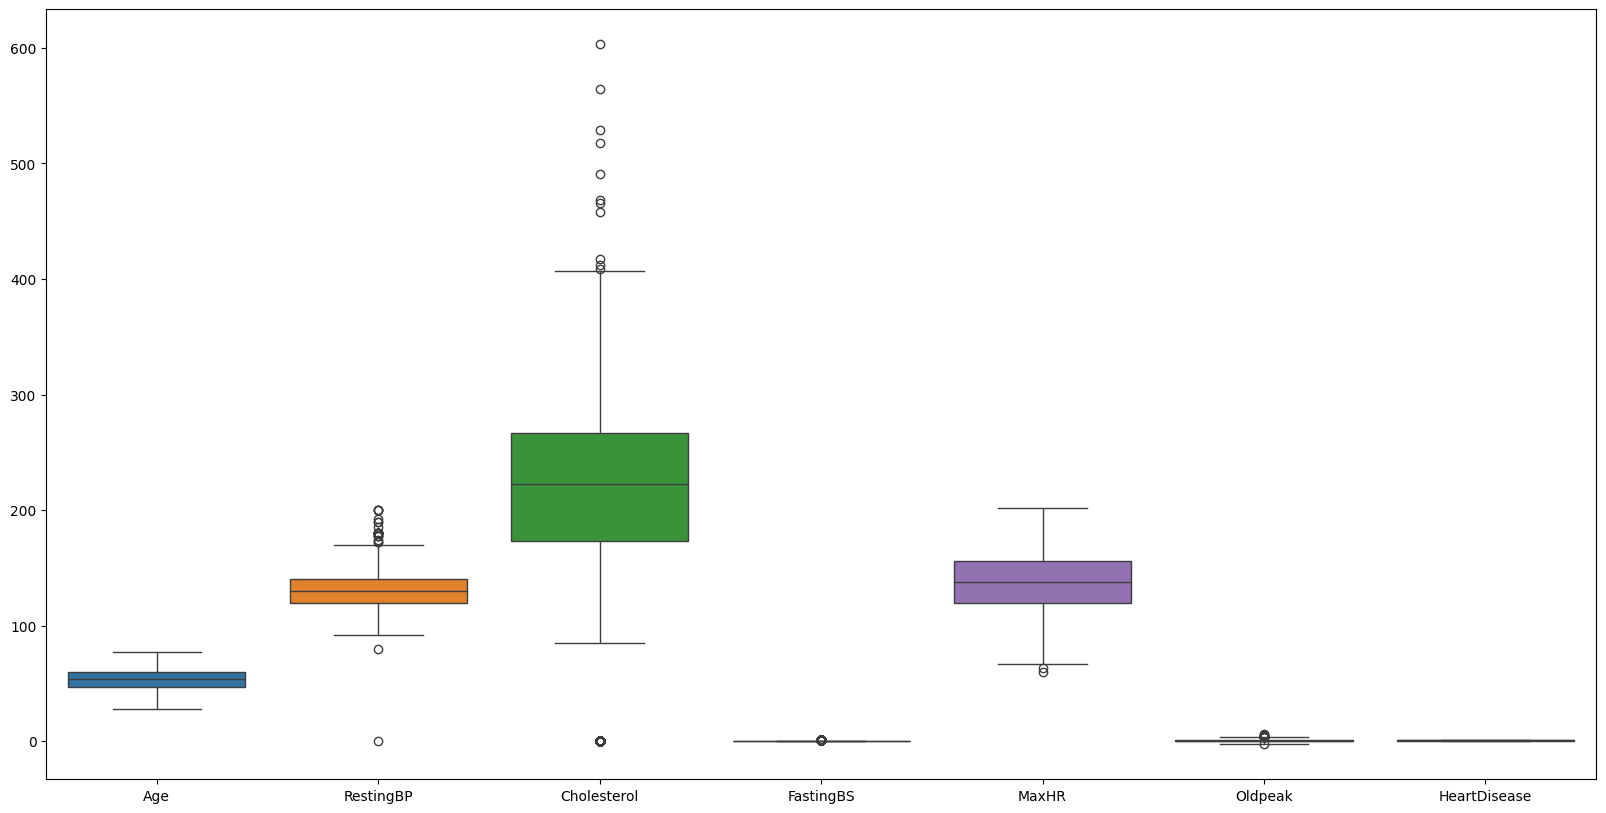

In [6]:
#checking outlier
plt.figure(figsize=(20,10))
sns.boxplot(df)

5. Train-test split

In [7]:
X = df.drop('HeartDisease', axis = 1)
y = df["HeartDisease"]

In [8]:
# one hot encoding and label encoding 
X= pd.get_dummies(X ,drop_first = True, dtype= int)
from sklearn.preprocessing  import LabelEncoder

label = LabelEncoder()
y = label.fit_transform(y)


In [9]:
from sklearn.model_selection import train_test_split
X_train ,X_test, y_train,y_test = train_test_split(X,y , test_size = 0.3,
                                                       random_state = 42 , stratify=y)

6. Scaling

In [10]:
from sklearn.preprocessing  import StandardScaler
scaler= StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

7. Model training & Evaluation


Logistic Regression

Train Accuracy : 0.8504672897196262
Test Accuracy  : 0.8840579710144928

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       123
           1       0.88      0.92      0.90       153

    accuracy                           0.88       276
   macro avg       0.89      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276



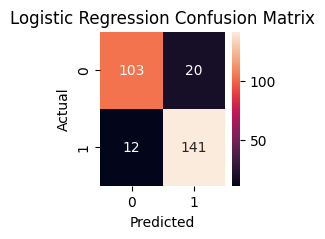

AUC Score : 0.9324087358520644


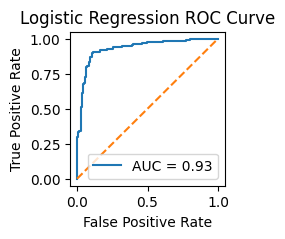


Cross Validation Scores :
[0.82170543 0.89147287 0.859375   0.859375   0.765625  ]
Average CV Score : 0.8395106589147285

Random Forest

Train Accuracy : 0.9049844236760125
Test Accuracy  : 0.8804347826086957

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.83      0.86       123
           1       0.87      0.92      0.90       153

    accuracy                           0.88       276
   macro avg       0.88      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276



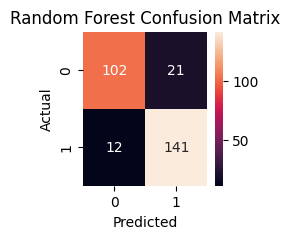

AUC Score : 0.9469684892927361


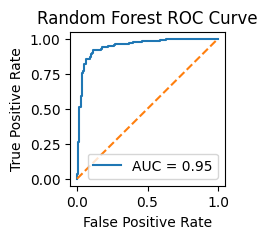


Cross Validation Scores :
[0.84496124 0.88372093 0.890625   0.875      0.7890625 ]
Average CV Score : 0.856673934108527

XGBoost

Train Accuracy : 0.9330218068535826
Test Accuracy  : 0.894927536231884

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       123
           1       0.90      0.91      0.91       153

    accuracy                           0.89       276
   macro avg       0.89      0.89      0.89       276
weighted avg       0.89      0.89      0.89       276



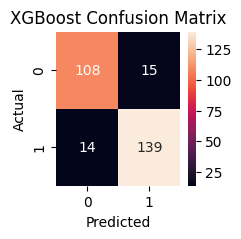

AUC Score : 0.9431425686805887


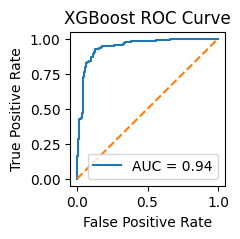


Cross Validation Scores :
[0.86821705 0.86046512 0.90625    0.8515625  0.8046875 ]
Average CV Score : 0.858236434108527


In [11]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import cross_val_score


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    # TRAINING
    model.fit(X_train, y_train)

    # PREDICTIONS
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    # ACCURACY
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"\n{model_name}\n")

    print("Train Accuracy :", train_acc)
    print("Test Accuracy  :", test_acc)

    # CLASSIFICATION REPORT
    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred_test))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(2,2))
    sns.heatmap(cm,
                annot=True,
                fmt='d')

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_confusion_matrix.png")

    plt.show()


    # ROC CURVE + AUC
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, threshold = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    print("AUC Score :", auc_score)

    plt.figure(figsize=(2,2))

    plt.plot(fpr, tpr,
             label=f"AUC = {auc_score:.2f}")

    plt.plot([0,1],[0,1],'--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"{model_name} ROC Curve")

    plt.legend()
    plt.savefig(f"{model_name}_roc_curve.png")

    plt.show()


    # CROSS VALIDATION
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5
    )

    print("\nCross Validation Scores :")
    print(cv_scores)

    print("Average CV Score :", cv_scores.mean())


# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)

evaluate_model(
    lr_model,
    X_train_scale,
    X_test_scale,
    y_train,
    y_test,
    "Logistic Regression"
)

# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Random Forest"
)

# XGBOOST
from xgboost import XGBClassifier

xg_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

evaluate_model(
    xg_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "XGBoost"
)

In [12]:
Best_model = rf_model

In [13]:
import joblib
joblib.dump(Best_model,"best_model.pkl")

['best_model.pkl']

In [14]:
print(X.columns)

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')
